<a href="https://colab.research.google.com/github/elhamod/IS834_Fall_2026/blob/main/Session%2003%20-%20Pandas%20I%20-%20Importing%20and%20Exploration/03_Analytics_with_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS834 — Session 3

Work through this notebook in Colab. The lecture cells are filled in and ready to run; the
**Exercises** are yours to complete — write your code in the `# Your code here` cells and your
reasoning in the `*Provide your answer here*` cells.

Every dataset is read straight from the course repository, so there is nothing to upload or install.

*Adapted from Brock Tibert's IS834 Fall 2025 session 3. Edited for Fall 2026 by Mohannad Elhamod.*

# Learning Goals

- Loading datasets into pandas
- Inspection and review
- Column summaries
- Unique values and value counts
- Selecting rows and columns
- Sorting

Cleaning the problems we find along the way is next session's job.

# Warmup Exercises

A quick check on last week's fundamentals before we open a dataset.


**Exercise 1.** Return all of the elements from `mylist` except `apple`.


In [ ]:
# Your code here
mylist = ['apple', 'banana', 'cherry']
x = []
for i in mylist:
    if i != 'apple':
        x.append(i)
print(x)   

['banana', 'cherry']


In [2]:
mylist = ['apple', 'banana', 'cherry']
y = [i for i in mylist if i != 'apple']
print(y)

['banana', 'cherry']


**Answer**

*Provide your answer here*

**Exercise 2.** Use `mylist` from above, and add strawberries to the list.


In [3]:
# Your code here
mylist.append('strawberry')
print(mylist)

['apple', 'banana', 'cherry', 'strawberry']


**Answer**

*Provide your answer here*

**Exercise 3.** For the dictionary below, do the following:

- a) identify all of the keys
- b) access the key `Salary`
- c) delete the key `Employee_ID`


In [2]:
employees = {
    'Employee_ID': [101, 102, 103, 104, 105],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Department': ['HR', 'Engineering', 'Marketing', 'Sales', 'HR'],
    'Salary': [60000, 80000, 75000, 50000, 72000]
}

# Your code here -- a) list the keys
employees.keys()

dict_keys(['Employee_ID', 'Name', 'Department', 'Salary'])

In [4]:
import pandas as pd
mydf = pd.DataFrame(employees)
mydf

,Employee_ID,Name,Department,Salary
0,101,Alice,HR,60000
1,102,Bob,Engineering,80000
2,103,Charlie,Marketing,75000
3,104,David,Sales,50000
4,105,Eva,HR,72000


In [5]:
# Your code here -- b) access the Salary key
employees['Salary']

[60000, 80000, 75000, 50000, 72000]

In [6]:
# Your code here -- c) delete the Employee_ID key
del employees['Employee_ID']
employees

{'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
 'Department': ['HR', 'Engineering', 'Marketing', 'Sales', 'HR'],
 'Salary': [60000, 80000, 75000, 50000, 72000]}

**Answer**

*Provide your answer here*

# Getting Started


Let's look at the dataset. It is a small survey extract, `sample-survey-data.csv`, which the next cell reads straight from the course repository.


###  Data Roles/Types

![](https://cdn1.byjus.com/wp-content/uploads/2021/12/Types-of-Data-in-Statistics.png)

Notes:

- Nominal data doesn't have an ordering (East, West regions), whereas Ordinal data retains a sorting (bronze, silver, gold).
- Discrete are data are countable values (# of rooms in a home).  Continuous can take on any value, and usually come from measurements (time to run a marathon, closing price of a stock).


**Question 1.** Data stored as a number is not always a quantity. Can you think of columns that arrive as numbers but are really labels?

**Answer**

*Provide your answer here*

### Dataset Structure



![](https://media.geeksforgeeks.org/wp-content/cdn-uploads/creating_dataframe1.png)


# pandas 101


## Ingestion


In [6]:
# pandas is pre-installed on Colab, so it only needs importing. "as pd" is the universal convention.
import pandas as pd

# Every data file this notebook uses is read straight from the course repository.
# There is nothing to upload: DATA is the folder those files live in.
DATA = "https://raw.githubusercontent.com/laglead/IS834_Fall_2026/main/data/"


In [7]:
# Read the survey data from the CSV that ships with this notebook.
# The survey file is read straight from the course repository -- nothing to upload.
df = pd.read_csv(DATA + "sample-survey-data.csv")


In [8]:
# A quick look at the first rows -- we will come back to inspection properly later in class.
df.head(3)


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...


In [9]:
type(df)

pandas.core.frame.DataFrame

Let's see a variety of the ways to save and read data via pandas (Image taken form: https://levelup.gitconnected.com/pandas-complete-guide-fba59b69598c).

![](https://snipboard.io/dkbpF0.jpg)


> worth nothing above assumes that pandas is imported as pd, and the dataframe you want to export is `df` in your session.




In [10]:
# Another csv, this time a plain file, read the same way from the course repository.
nvda = pd.read_csv(DATA + "nvda.csv")

type(nvda)


pandas.core.frame.DataFrame

![](https://images.ctfassets.net/lzny33ho1g45/1axzhgm4thtZi42OxsNeZk/8414378ccb84bbb5586dc9f56315731c/Google_Sheets_vs_Excel_hero.jpg?fm=jpg&q=31&fit=thumb&w=800&h=300)

Documentation: https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html


In [11]:
# Excel works the same way. Colab already has openpyxl, the library pandas uses to open .xlsx files.
xl = pd.read_excel(DATA + 'sales.xlsx')

xl.head(3)


,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,18606,Not Specified,0.01,2.88,0.50,2,Janice Fletcher,Regular Air,Corporate,Office Supplies,...,Central,Illinois,Addison,60101,2012-05-28,2012-05-30,1.32,2,5.90,88525
1,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2010-07-07,2010-07-08,4.56,4,13.01,88522
2,23086,Not Specified,0.03,6.68,6.15,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-28,-47.64,7,49.92,88523


In [12]:
# But that workbook has three worksheets! sheet_name=None reads them ALL and returns a dictionary.
wb = pd.read_excel(DATA + 'sales.xlsx', sheet_name="Returns") #1st sheet if sheet_name is not declared

type(wb)
wb.head()


,Order ID,Status
0,65,Returned
1,612,Returned
2,614,Returned
3,678,Returned
4,710,Returned


In [13]:
type(wb)

pandas.core.frame.DataFrame

# Follow up Questions and Exercises — Part 1: loading data


**Exercise 4.** Review the keys of the dictionary that `pd.read_excel(..., sheet_name=None)` returned.


In [14]:
# Your code here
wb = pd.read_excel(DATA + 'sales.xlsx', sheet_name=None)
wb.keys()
# wb

dict_keys(['Orders', 'Returns', 'Users'])

In [18]:
wb.items()

dict_items([('Orders',       Row ID Order Priority  Discount  Unit Price  Shipping Cost  Customer ID  \
0      18606  Not Specified      0.01        2.88           0.50            2   
1      20847           High      0.01        2.84           0.93            3   
2      23086  Not Specified      0.03        6.68           6.15            3   
3      23087  Not Specified      0.01        5.68           3.60            3   
4      23088  Not Specified      0.00      205.99           2.50            3   
...      ...            ...       ...         ...            ...          ...   
9421   20275       Critical      0.06       35.89          14.72         3402   
9422   20276       Critical      0.00        3.34           7.49         3402   
9423   24491  Not Specified      0.08      550.98          45.70         3402   
9424   25914           High      0.10      105.98          13.99         3403   
9425   24492  Not Specified      0.09        7.78           2.50         3403   

    

**Answer**

*Provide your answer here*

**Exercise 5.** Based on what you know about dictionaries, experiment! Can you create a variable called `users` that is a pandas DataFrame?

> HINT: Remember that dictionaries in python are key:value/object pairs.


In [19]:
# Your code here
users = pd.read_excel(DATA + 'sales.xlsx', sheet_name=None)['Users']
type(users)
users

,Region,Manager
0,Central,Chris
1,East,Erin
2,South,Sam
3,West,William


**Answer**

*Provide your answer here*

## Inspection


In [15]:
# Back to the small survey dataset.
df.head(7)


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."


Important considerations

- Python is 0-based
- pandas thinks in rows/columns.  We will start to break that concept down with commands.
- A column of data is mapped to a single data type. All values must be strings, or numbers.  If the data are mixed, all data are `cast` to  one data type.
- The numbers along the rows are referred to as the row index.
- Columns can/usually have names, and this is also an index. It's a column index.


In [20]:
# .shape reports (number of rows, number of columns) -- the first thing to check after any load.
df.shape


(12, 10)

In [21]:
# The column names live in their own index object.
df.columns


Index(['id', 'Age', 'userid', 'Income', 'Education', 'Satisfaction',
       'Recommend', 'Region', 'Signup Date', 'comment'],
      dtype='object')

In [18]:
# .to_list() turns them into a plain Python list, which is easier to work with.
df.columns.to_list()


['id',
 'Age',
 'userid',
 'Income',
 'Education',
 'Satisfaction',
 'Recommend',
 'Region',
 'Signup Date',
 'comment']

In [19]:
# A neat trick: "in" asks whether a column exists, and it is case sensitive.
print('Region' in df.columns)
print('education' in df.columns)   # False -- the column is spelled Education
print('Status' in df.columns)


True
False
False


In [20]:
# .info() gives the columns, their types, and how many non-missing values each one holds.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            12 non-null     int64  
 1   Age           11 non-null     float64
 2   userid        12 non-null     object 
 3   Income        12 non-null     int64  
 4   Education     12 non-null     object 
 5   Satisfaction  11 non-null     float64
 6   Recommend     11 non-null     object 
 7   Region        11 non-null     object 
 8   Signup Date   12 non-null     object 
 9   comment       12 non-null     object 
dtypes: float64(2), int64(2), object(6)
memory usage: 1.1+ KB


In [21]:
# .tail() shows the end of the data, which often looks different from the start.
df.tail(3)


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
9,9,NaN,user9,56000,Bachelor,2.0,No,NaN,2023-10-01,The service was terrible and the support team ...
10,10,148.0,user10,80000,Master,5.0,Yes,South,2025-04-12,I am extremely dissatisfied and very disappoin...
11,11,25.0,user3,78643,High School,2.0,No,North,2026-02-10,This was the worst experience I’ve ever had — ...


In [22]:
# head(20) on a 12-row dataset simply shows everything.
df.head(20)


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...
8,8,29.0,user8,40000,High School,4.0,NaN,West,2024-09-27,Very poor quality — I regret buying this produ...
9,9,NaN,user9,56000,Bachelor,2.0,No,NaN,2023-10-01,The service was terrible and the support team ...


> Read down the Dtype column and note which columns pandas is treating as numbers and which it is not. The exact label it prints for a text column depends on the version of pandas you are running, so read what is on your own screen rather than memorising a name.


Now lets look at the output of info one more time


In [23]:
# Read the Non-Null Count column: any number below the row count means missing values.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            12 non-null     int64  
 1   Age           11 non-null     float64
 2   userid        12 non-null     object 
 3   Income        12 non-null     int64  
 4   Education     12 non-null     object 
 5   Satisfaction  11 non-null     float64
 6   Recommend     11 non-null     object 
 7   Region        11 non-null     object 
 8   Signup Date   12 non-null     object 
 9   comment       12 non-null     object 
dtypes: float64(2), int64(2), object(6)
memory usage: 1.1+ KB


We can see that the shape exists, 12 entries, 10 columns, but based on the Non-Null column, some rows have missing data


In [24]:
# Sorting is usually a reporting step, done after summarizing -- but it is also a fast way to spot bad values.
df.sort_values('Age').head(20)


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
11,11,25.0,user3,78643,High School,2.0,No,North,2026-02-10,This was the worst experience I’ve ever had — ...
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
8,8,29.0,user8,40000,High School,4.0,NaN,West,2024-09-27,Very poor quality — I regret buying this produ...
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."


In [25]:
# ascending=False flips it. An Age of 148 at the top is the kind of thing sorting is for.
df.sort_values('Age', ascending=False).head(20)


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
10,10,148.0,user10,80000,Master,5.0,Yes,South,2025-04-12,I am extremely dissatisfied and very disappoin...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
8,8,29.0,user8,40000,High School,4.0,NaN,West,2024-09-27,Very poor quality — I regret buying this produ...
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
11,11,25.0,user3,78643,High School,2.0,No,North,2026-02-10,This was the worst experience I’ve ever had — ...


> Sorting does not change `df`. Every one of these commands returns a *new* DataFrame and leaves the original alone, which is why we can keep calling `df` and get the original order back.


In [26]:
df

,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...
8,8,29.0,user8,40000,High School,4.0,NaN,West,2024-09-27,Very poor quality — I regret buying this produ...
9,9,NaN,user9,56000,Bachelor,2.0,No,NaN,2023-10-01,The service was terrible and the support team ...


# Follow up Questions and Exercises — Part 2: inspection


**Exercise 6.** Use the NVIDIA dataset. How many rows and columns are there?


In [27]:
# Your code here
nvidia = pd.read_csv(DATA + "nvda.csv")
nvidia.head()
nvidia.shape
nvidia.describe(include='all')

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1256,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03,1256.000000,1256.000000
unique,1256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-09-18 00:00:00-04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,57.275551,58.275602,56.167898,57.282980,4.049751e+08,0.000092,0.011146
std,NaN,50.687969,51.432671,49.775996,50.657163,1.803239e+08,0.000805,0.303819
min,NaN,10.957835,11.720920,10.800024,11.213527,4.930821e+07,0.000000,0.000000
25%,NaN,17.205586,17.667084,16.828680,17.224944,2.586050e+08,0.000000,0.000000
50%,NaN,28.738217,29.143904,28.050744,28.875112,3.891296e+08,0.000000,0.000000
75%,NaN,104.514346,107.779875,101.692206,105.240814,5.139898e+08,0.000000,0.000000


**Answer**

*Provide your answer here*

**Exercise 7.** List out the column names as a Python list.


In [28]:
# Your code here
list(nvidia.columns)

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

**Answer**

*Provide your answer here*

**Exercise 8.** Sort the data descending by closing price and show the 5 largest values.


In [29]:
# Your code here
nvidia.sort_values('Close', ascending=False).head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
1229,2025-08-12 00:00:00-04:00,182.949688,184.469591,179.449885,183.149673,145485700,0.0,0.0
1227,2025-08-08 00:00:00-04:00,181.539768,183.289670,180.389824,182.689697,123396700,0.0,0.0
1228,2025-08-11 00:00:00-04:00,182.039734,183.829627,180.239833,182.049728,138323200,0.0,0.0
1231,2025-08-14 00:00:00-04:00,179.739859,183.009679,179.449882,182.009735,129554000,0.0,0.0
1233,2025-08-18 00:00:00-04:00,180.589816,182.929681,180.579807,181.999725,132008000,0.0,0.0


**Answer**

*Provide your answer here*

**Exercise 9.** Print out the info of the dataset. As an analyst, is there anything about how pandas is storing the data that we might want to change or enhance? TRICKY!


In [30]:
# Your code here -- step 1: print the info for the dataset
nvidia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          1256 non-null   object 
 1   Open          1256 non-null   float64
 2   High          1256 non-null   float64
 3   Low           1256 non-null   float64
 4   Close         1256 non-null   float64
 5   Volume        1256 non-null   int64  
 6   Dividends     1256 non-null   float64
 7   Stock Splits  1256 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 78.6+ KB


In [31]:
# Your code here -- step 2: fix whatever the Dtype column reveals


**Answer**

*Provide your answer here*

## Summaries and Basic Aggregations


In [38]:
# .describe() is the fastest way to see the shape of every numeric column at once.
df.describe()


,id,Age,Income,Satisfaction
count,12.000000,11.000000,12.000000,11.000000
mean,5.833333,46.454545,52303.583333,3.727273
std,3.214550,35.226023,42588.670596,1.103713
min,1.000000,23.000000,-68000.000000,2.000000
25%,3.750000,28.000000,41500.000000,3.000000
50%,5.500000,38.000000,58000.000000,4.000000
75%,8.250000,48.500000,78982.250000,4.500000
max,11.000000,148.000000,91000.000000,5.000000


**Question 2.** Take two minutes on the `.describe()` output above. What do you notice about the data it returned -- and about the data it did *not* return?

**Answer**

*Provide your answer here*

In [39]:
# include="all" adds the text columns, with count/unique/top/freq instead of means.
df.describe(include="all")


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
count,12.000000,11.000000,12,12.000000,12,11.000000,11,11,12,12
unique,NaN,NaN,10,NaN,5,NaN,3,5,11,12
top,NaN,NaN,user4,NaN,Bachelor,NaN,Yes,South,2025-01-02,Absolutely fantastic service — I am extremely ...
freq,NaN,NaN,2,NaN,4,NaN,6,3,2,1
mean,5.833333,46.454545,NaN,52303.583333,NaN,3.727273,NaN,NaN,NaN,NaN
std,3.214550,35.226023,NaN,42588.670596,NaN,1.103713,NaN,NaN,NaN,NaN
min,1.000000,23.000000,NaN,-68000.000000,NaN,2.000000,NaN,NaN,NaN,NaN
25%,3.750000,28.000000,NaN,41500.000000,NaN,3.000000,NaN,NaN,NaN,NaN
50%,5.500000,38.000000,NaN,58000.000000,NaN,4.000000,NaN,NaN,NaN,NaN
75%,8.250000,48.500000,NaN,78982.250000,NaN,4.500000,NaN,NaN,NaN,NaN


In [40]:
# .T transposes the summary, which is easier to read once you have more than a few columns.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,12.0,5.833333,3.214550,1.0,3.75,5.5,8.25,11.0
Age,11.0,46.454545,35.226023,23.0,28.00,38.0,48.50,148.0
Income,12.0,52303.583333,42588.670596,-68000.0,41500.00,58000.0,78982.25,91000.0
Satisfaction,11.0,3.727273,1.103713,2.0,3.00,4.0,4.50,5.0


![](https://miro.medium.com/v2/resize:fit:1400/1*RZ1nbLkRCn-8Hu7DK3I4jA.png)


- A Series is just a name for a column of data in pandas
- Often times we do not have to worry about creating them by hand, as the `pd.read_*` utilties will handle this for us.
- Think of a Series as a list, which is the `value` of a Python dictionary.


In [41]:
# A single column of a DataFrame is a Series -- the DataFrame is the table, the Series is one column of it.
age = df['Age']

print(type(age))
age.head(3)


<class 'pandas.core.series.Series'>


,Age
0,23.0
1,45.0
2,31.0


In [42]:
# In practice we rarely want the column itself; we want a number that summarizes it.
df['Age'].mean()


np.float64(46.45454545454545)

In [43]:
# By default the mean ignores missing values. skipna=False refuses to, and reports NaN instead.
print(df['Age'].mean())
print(df['Age'].mean(skipna=False))


46.45454545454545
nan


**Question 3.** The cell above printed the mean of `Age` twice and got two different results, one of them `NaN`. Why do they differ, and which of the two would you report?

**Answer**

*Provide your answer here*

In [44]:
# .describe() works on a single column too.
df['Age'].describe()


,Age
count,11.000000
mean,46.454545
std,35.226023
min,23.000000
25%,28.000000
50%,38.000000
75%,48.500000
max,148.000000


> Above I am using the `.` reference to access the column name as an attribute.  I can do this because the column name __does not have any spaces__ in the name.  As a rule, I tend to "clean" column names so that I can use this type of reference in my code, but in practice, there is no functional difference between `df['Age']` and `df.Age`


In [45]:
# We are not limited to the mean -- type df.Age. and press Tab to see what else a column can do.
print(df.Age.min())
print(df.Age.max())
print(df.Age.median())
print(df.Age.quantile(.25))


23.0
148.0
38.0
28.0


In [46]:
# For categorical data, start with the list of distinct values.
df.Region.unique()


array(['Northeast', 'Midwest', 'South', 'West', nan, 'North'],
      dtype=object)

> Read that output carefully — `nan` is in the list. `.unique()` is the fastest way to see every distinct label a column actually contains, blanks included, and it is where you catch the near-duplicates (`NY` and `New York`, `Card` and `Cards`) that would otherwise split one group into two.

In [47]:
df['Education'].unique()

array(['Bachelor', 'Master', 'Associate', 'Doctorate', 'High School'],
      dtype=object)

In [48]:
# .nunique() counts the distinct values instead of listing them.
df.Region.nunique()


5

<img src="https://sharpsight.ai/wp-content/uploads/2021/07/pandas-value-counts_FEATURED-IMAGE.png" width="400">


In [49]:
# .value_counts() counts the rows per category, sorted largest first.
df.Region.value_counts()


,count
Region,
South,3
West,3
Northeast,2
Midwest,2
North,1


In [50]:
df.Region

,Region
0,Northeast
1,Midwest
2,South
3,West
4,West
5,Northeast
6,South
7,Midwest
8,West
9,NaN


In [51]:
# Missing values are excluded by default. dropna=False shows them, which is usually what you want.
df.Region.value_counts(dropna=False)


,count
Region,
West,3
South,3
Midwest,2
Northeast,2
NaN,1
North,1


**Question 4.** The two `.value_counts()` tables above do not add up to the same number of respondents. Who is missing from the first one, and what does that do to a percentage built on it?

**Answer**

*Provide your answer here*

# Follow up Questions and Exercises — Part 3: summaries and aggregations

In [53]:
# Starter code: read the workbook again and load just the Orders sheet.
orders = pd.read_excel(DATA + 'sales.xlsx', sheet_name='Orders')

orders.head(3)


,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,18606,Not Specified,0.01,2.88,0.50,2,Janice Fletcher,Regular Air,Corporate,Office Supplies,...,Central,Illinois,Addison,60101,2012-05-28,2012-05-30,1.32,2,5.90,88525
1,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2010-07-07,2010-07-08,4.56,4,13.01,88522
2,23086,Not Specified,0.03,6.68,6.15,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-28,-47.64,7,49.92,88523


**Exercise 10.** How many rows and columns are in the `orders` dataframe?


In [46]:
# Your code here
# orders.info()
# orders.columns
len(orders.columns)

24

In [54]:
orders.shape[1]

24

**Answer**

*Provide your answer here*

**Exercise 11.** What is the average discount for the full dataset?


In [55]:
# Your code here
orders.Discount.mean()

np.float64(0.0496276257161044)

**Answer**

*Provide your answer here*

**Exercise 12.** For each product category, show the frequency of each value.


In [56]:
# Your code here
orders['Product Category'].value_counts()

,count
Product Category,
Office Supplies,5181
Technology,2312
Furniture,1933


**Answer**

*Provide your answer here*

**Exercise 13.** Tricky! Can you adjust the values so instead of the counts, it's a percentage of the total?

> TIP: https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html


In [49]:
# Your code here
orders['Product Category'].value_counts(normalize=True)

,proportion
Product Category,
Office Supplies,0.549650
Technology,0.245279
Furniture,0.205071


**Answer**

*Provide your answer here*

## Row and Column Selection


In [81]:
# Selecting a single column gives a Series, and everything we did above still applies to it.
df['Age'].tail(3)


,Age
9,NaN
10,148.0
11,25.0


In [ ]:
# .sample() draws random rows; random_state makes that draw repeatable.
df.Age.sample(3, random_state=42)


,Age
10,148.0
9,NaN
0,23.0


In [106]:
df[['Age','Education']].sample(3)

,Age,Education
8,29.0,High School
9,NaN,Bachelor
5,27.0,Bachelor


In [77]:
# Pass a LIST of column names to keep several columns -- your Python fundamentals showing up again.
cols_to_keep = ['Age', 'Education']
df2 = df[cols_to_keep]

df2.head(3)


,Age,Education
0,23.0,Bachelor
1,45.0,Master
2,31.0,Associate


In [53]:
mydf = df[['Age', 'Education']]
mydf.head(3)

,Age,Education
0,23.0,Bachelor
1,45.0,Master
2,31.0,Associate


In [54]:
# Confirm what you built: still a DataFrame, same rows, fewer columns.
print(type(df2))
print(df2.shape)


<class 'pandas.core.frame.DataFrame'>
(12, 2)


In [55]:
# The list can be written inline, which is what you will see most often.
df[['Age', 'Education', 'Income']].head(3)


,Age,Education,Income
0,23.0,Bachelor,35000
1,45.0,Master,-68000
2,31.0,Associate,42000


In [56]:
# One bracket gives a Series, two brackets give a DataFrame -- a distinction that trips everyone up once.
print(type(df['Age']))
print(type(df[['Age']]))


<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


**Why you care.** A Series has no column headers and cannot hold a second column, so `.merge()`, `.to_excel()` and most plotting calls expect a DataFrame. If pandas ever complains that a Series has no attribute you are sure exists, count your brackets first.


In [57]:
# Rows are selected with a True/False test, applied to every row at once.
df[df.Age > 40]


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...
10,10,148.0,user10,80000,Master,5.0,Yes,South,2025-04-12,I am extremely dissatisfied and very disappoin...


In [110]:
df_old = df[df.Age > 130]
print(df_old)
shape = df_old.shape
print(shape)

n_rows = shape[0]

if (n_rows > 0):
    print('Someone\'s age is too high')

    id    Age  userid  Income Education  Satisfaction Recommend Region  \
10  10  148.0  user10   80000    Master           5.0       Yes  South   

   Signup Date                                            comment  
10  2025-04-12  I am extremely dissatisfied and very disappoin...  
(1, 10)
Someone's age is too high


In [58]:
# The same idea on a text column. Watch the result count -- the file also contains a lowercase "no".
df[df.Recommend == 'Yes']


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."
10,10,148.0,user10,80000,Master,5.0,Yes,South,2025-04-12,I am extremely dissatisfied and very disappoin...


**Exercise 14.** The cell above kept the rows where `Recommend` is `'Yes'` and found 6 of them. Run the same filter for `'No'`, count the rows, then compare that count with `df.Recommend.value_counts(dropna=False)`. Do the two agree?

In [59]:
# Your code here
df[df['Recommend'] == 'No']

,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...
9,9,NaN,user9,56000,Bachelor,2.0,No,NaN,2023-10-01,The service was terrible and the support team ...
11,11,25.0,user3,78643,High School,2.0,No,North,2026-02-10,This was the worst experience I’ve ever had — ...


**Answer**

*Provide your answer here*

In [60]:
df.Recommend.value_counts(dropna=False)

,count
Recommend,
Yes,6
No,4
no,1
NaN,1


In [57]:
# .isin() checks membership in a list -- far cleaner than chaining several == conditions.
regions = ['Northeast', 'Midwest']
df[df['Region'].isin(regions)]


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...


In [74]:
df[(df.Region == 'Northeast') | (df.Region == 'Midwest')]

,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
0,1,23.0,user1,35000,Bachelor,4.0,Yes,Northeast,2025-05-01,Absolutely fantastic service — I am extremely ...
1,2,45.0,user2,-68000,Master,5.0,Yes,Midwest,2024-05-03,The product quality is excellent and the exper...
5,5,27.0,user5,50000,Bachelor,NaN,no,Northeast,2024-11-12,"It was okay — not amazing, not terrible, just ..."
7,7,41.0,user7,72000,Bachelor,3.0,No,Midwest,2024-12-10,The experience was frustrating and somewhat di...


In [75]:
# The tilde negates the expression: "region is NOT in that list".
df[~df['Region'].isin(regions)]


,id,Age,userid,Income,Education,Satisfaction,Recommend,Region,Signup Date,comment
2,3,31.0,user3,42000,Associate,3.0,No,South,2024-04-09,I really enjoyed the fast delivery and friendl...
3,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"Overall a good experience, though a few minor ..."
4,4,52.0,user4,91000,Doctorate,4.0,Yes,West,2025-01-02,"The product works fine, but I am slightly disa..."
6,6,38.0,user6,60000,Master,5.0,Yes,South,2023-05-14,"I am unhappy with the slow shipping, but custo..."
8,8,29.0,user8,40000,High School,4.0,NaN,West,2024-09-27,Very poor quality — I regret buying this produ...
9,9,NaN,user9,56000,Bachelor,2.0,No,NaN,2023-10-01,The service was terrible and the support team ...
10,10,148.0,user10,80000,Master,5.0,Yes,South,2025-04-12,I am extremely dissatisfied and very disappoin...
11,11,25.0,user3,78643,High School,2.0,No,North,2026-02-10,This was the worst experience I’ve ever had — ...


In [78]:
# Rows and columns together: filter first, then hand the column list to the result.
df[df.Region == 'South'][cols_to_keep]


,Age,Education
2,31.0,Associate
6,38.0,Master
10,148.0,Master


In [79]:
# A cleaner way to say the same thing: .loc[row_filter, column_filter].
df.loc[df.Region == 'South', cols_to_keep]


,Age,Education
2,31.0,Associate
6,38.0,Master
10,148.0,Master


> NOTE:  There are other ways to filter data in Pandas, but I generally teach these two methods because they are the most popular and I believe they support a mental model that is easier to understand in my opinion


# Follow up Questions and Exercises — Part 4: row and column selection


**Exercise 15.** How many rows in the `orders` dataset have a Unit Price greater than 100? Save the result as a new dataframe called `q1`.


In [80]:
# Your code here
q1 = orders[orders['Unit Price'] > 100]
q1.shape[0]
# type(q1)
# q1.sort_values('Unit Price', ascending=True)

2156

In [88]:
# q1['Unit Price'].value_counts()
q1

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
4,23088,Not Specified,0.00,205.99,2.50,3,Bonnie Potter,Express Air,Corporate,Technology,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-27,998.202300,8,1446.67,88523
6,25549,Low,0.08,120.97,26.30,3,Bonnie Potter,Delivery Truck,Corporate,Technology,...,West,Washington,Anacortes,98221,2013-07-01,2013-07-08,1001.445300,12,1451.37,88526
7,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,West,California,San Gabriel,91776,2010-12-13,2010-12-15,4390.366500,12,6362.85,90193
14,20876,Medium,0.08,140.98,36.09,8,Melanie Garner,Delivery Truck,Home Office,Furniture,...,East,New Hampshire,Bedford,3110,2012-12-25,2012-12-26,-158.740000,5,705.47,90199
15,20877,Medium,0.10,286.85,61.76,9,Lorraine Houston,Delivery Truck,Home Office,Furniture,...,East,New Jersey,Camden,8101,2012-12-25,2012-12-27,-346.615198,8,1794.27,90199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9408,22194,High,0.00,160.98,35.02,3398,Marc McDaniel,Delivery Truck,Small Business,Furniture,...,Central,Illinois,Decatur,62521,2012-11-25,2012-11-26,1790.426000,41,7158.10,87544
9417,23413,Critical,0.07,115.79,1.99,3400,Florence Gold,Regular Air,Corporate,Technology,...,East,West Virginia,Fairmont,26554,2013-04-27,2013-04-29,606.309900,8,878.71,87546
9420,18329,High,0.08,212.60,52.20,3402,Frederick Cole,Delivery Truck,Consumer,Furniture,...,East,West Virginia,Charleston,25314,2011-04-12,2011-04-12,-513.790420,10,1969.31,87531
9423,24491,Not Specified,0.08,550.98,45.70,3402,Frederick Cole,Delivery Truck,Consumer,Furniture,...,East,West Virginia,Charleston,25314,2013-09-12,2013-09-14,-1225.029097,4,2215.93,87533


**Answer**

*Provide your answer here*

**Exercise 16.** For this filtered dataset, count the number of rows by Region.


In [ ]:
# Your code here
q1['Region'].value_counts()

,count
Region,
Central,669
East,538
West,535
South,414


**Answer**

*Provide your answer here*

# Putting it all together!


**Exercise 17.** You are a sales analyst at an office supply company. The Sales Director wants to understand the total sales for each Region. Are the regions all performing the same, or are there some that may show signs of struggling based on this data?

HINT:  You may need to perform the same task a few times, but we covered everything that you need for this above!

This uses the orders data from the Sales workbook.

In [2]:
orders = pd.read_excel(DATA+'sales.xlsx')
orders


NameError: name 'pd' is not defined

In [90]:
# Your code here -- step 1: what regions are in the data, and are the labels clean?
# orders.Region.value_counts()
print(orders.Region.unique())
orders['Region'].value_counts(dropna=False)

['Central' 'West' 'East' 'South']


,count
Region,
Central,2899
East,2289
West,2284
South,1954


In [91]:
# Your code here -- step 2: total sales per region, and each region's share of the total
region_sales_sum = orders[['Region','Sales']].groupby('Region').sum()
region_sales_sum

,Sales
Region,
Central,2540341.62
East,2422804.68
South,1597346.22
West,2391438.80


In [70]:
region_sales_sum = orders.groupby('Region')['Sales'].sum()
region_sales_sum

,Sales
Region,
Central,2540341.62
East,2422804.68
South,1597346.22
West,2391438.80


In [93]:
a = []
for i in orders.Region.unique():
    sum = orders.Sales[orders.Region == i].sum()
    share = orders.Sales[orders.Region == i].sum() / orders.Sales.sum()
    a.append({'Region':i, 
              'Sales Sum':sum, 
              'Sales Share':share})
dfa = pd.DataFrame(a)
dfa

# dfa['Sales Share'].sum()


,Region,Sales Sum,Sales Share
0,Central,2540341.62,0.283776
1,West,2391438.80,0.267142
2,East,2422804.68,0.270646
3,South,1597346.22,0.178436


In [1]:
for i in orders.Region.unique():
    sum = orders.Sales[orders.Region == i].sum()
    share = orders.Sales[orders.Region == i].sum() / orders.Sales.sum()
    # print('Total sales in '+ i + ' is: ' + str(sum.round(2)) + ', ' + 'it is ' + str(share.round(2)*100) + ' X of the Total sales')
    print(f'Total sales in {i} is: {sum.round(2)}, it is {(share*100).round(2)} % of the Total sales')

NameError: name 'orders' is not defined

In [122]:
# Your code here -- step 3: orders placed and average order value per region, then a chart
b = []
for i in orders.Region.unique():
    placed = orders['Quantity ordered new'][orders.Region == i].sum()
    # avg = orders.Sales[orders.Region == i].sum() / orders.Sales[orders.Region == i].count()
    avg = orders.Sales[orders.Region == i].mean()
    b.append({'Region':i, 'Orders Placed':placed, 'Average Order Value':avg})
dfb = pd.DataFrame(b)
dfb


,Region,Orders Placed,Average Order Value
0,Central,38083,876.282035
1,West,33739,1047.039755
2,East,34833,1058.455518
3,South,23409,817.475036


In [74]:
dfb['Orders Placed']

,Orders Placed
0,38083
1,33739
2,34833
3,23409


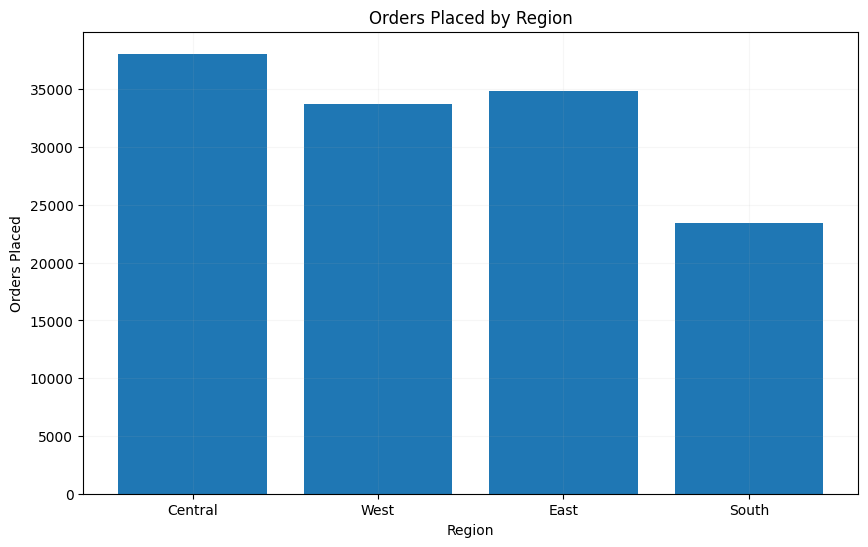

In [ ]:
import matplotlib.pyplot as plt

# dfc.Region
plt.figure(figsize=(10, 6))

plt.bar(dfb.Region, dfb['Orders Placed'])

plt.title('Orders Placed by Region')
plt.xlabel('Region')
plt.ylabel('Orders Placed')
plt.grid(True, alpha=.1)
plt.show()

<BarContainer object of 4 artists>

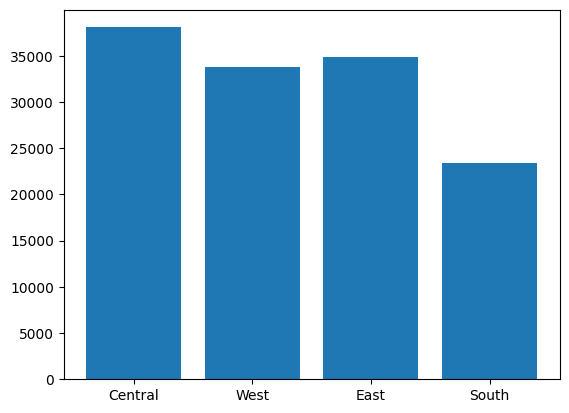

In [ ]:
fig, ax1 = plt.subplots()
ax1.bar(dfb.Region, dfb['Orders Placed'], zorder=1)
# ax2 = ax1.twinx()
# ax2.plot(dfb.Region, dfb['Average Order Value'], zorder=2, c='red')

**Answer**

*Provide your answer here*

# Next Session: Cleaning

We answered the Sales Director's question, but look at what we walked past on the way.

- An `Age` of **148**, which sorting turned up in one line.
- A `Recommend` column that answers both `No` and `no`, so any count of one understates the other.
- Blanks in `Age`, `Satisfaction` and `Region`.

Every one of those is still in the file. Exploration finds problems; it does not fix them.

Session 4 is the fixing -- and, more to the point, defending each fix. "Clean the data" is never a
single command. It is a series of judgement calls, and every one of them changes the numbers you end
up reporting.